## **Name: Chirag Chaudhari**
## **Roll no: 24102A2003**
## **Branch: CMPN-A**
## **Problem Statement-5: Social Network Analysis with R**

In [ ]:
install.packages("igraph")
library(igraph)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




## **Create Graphs**

In [ ]:
# Undirected graph with 7 nodes
g <- make_graph(c(1,2, 2,3, 3,4, 4,1), directed = FALSE, n = 7)

g1 <- make_graph(c("Amy", "Ram", "Ram", "Li", "Li", "Amy",
                   "Amy", "Li", "Kate", "Li"),
                 directed = TRUE)

print(g1)

IGRAPH 28c9f3a DN-- 4 5 -- 
+ attr: name (v/c)
+ edges from 28c9f3a (vertex names):
[1] Amy ->Ram Ram ->Li  Li  ->Amy Amy ->Li  Kate->Li 


## **Calculate Network Measures**

In [ ]:
print("--- Degrees ---")
degree(g1, mode = 'all')
degree(g1, mode = 'in')
degree(g1, mode = 'out')

print("--- Network Properties ---")
diameter(g1, directed = FALSE, weights = NA)
edge_density(g1, loops = FALSE)


print("--- Reciprocity ---")
reciprocity(g1)

print("--- Centrality ---")
closeness(g1, mode = 'all', weights = NA)
betweenness(g1, directed = TRUE, weights = NA)
edge_betweenness(g1, directed = TRUE, weights = NA)

[1] "--- Degrees ---"


Amy  Ram   Li Kate 
   3    2    4    1

Amy  Ram   Li Kate 
   1    1    3    0

Amy  Ram   Li Kate 
   2    1    1    1

[1] "--- Network Properties ---"


...

[1] 0.4

[1] "--- Centrality ---"


Amy       Ram        Li      Kate 
0.2500000 0.2500000 0.3333333 0.2000000

Amy  Ram   Li Kate 
   2    0    3    0

[1] 3 2 5 1 3

## **Read the Dataset**

In [ ]:
data <- read.csv('https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv', header = TRUE)

y <- data.frame(data$first, data$second)
head(y)

,data.first,data.second
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE


## **Create the Network & Plot Histogram**

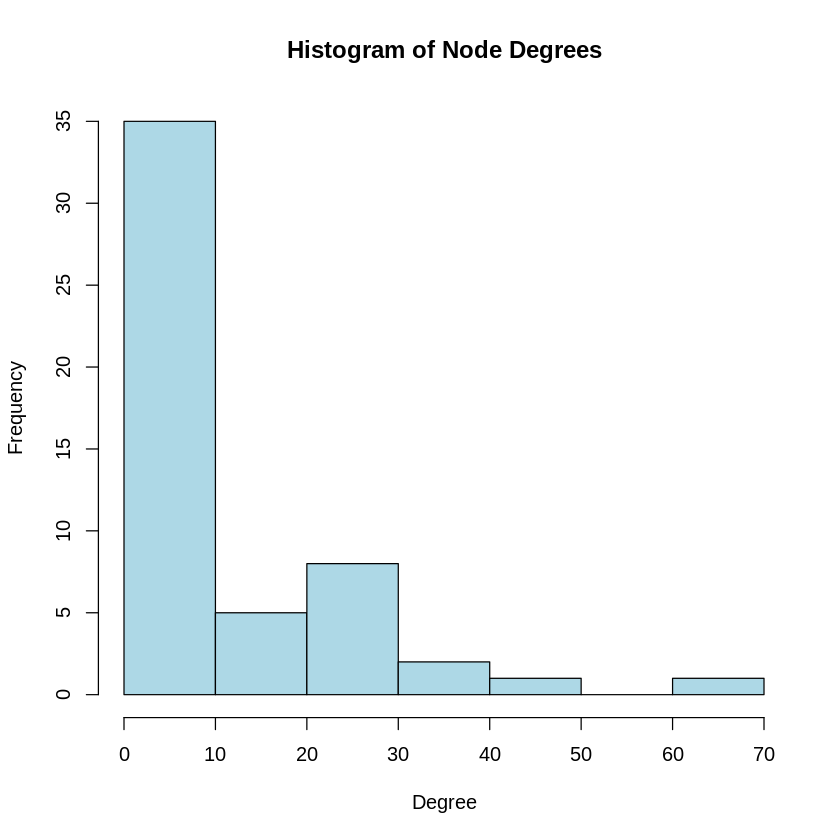

In [ ]:
# Create network
net <- graph_from_data_frame(y, directed = TRUE)

# Assign names to labels and calculate node degrees
V(net)$label <- V(net)$name
V(net)$degree <- degree(net)

# Plot a histogram of node degrees
hist(V(net)$degree, main = "Histogram of Node Degrees", xlab = "Degree", col = "lightblue")

## **Network Diagram with Layouts**

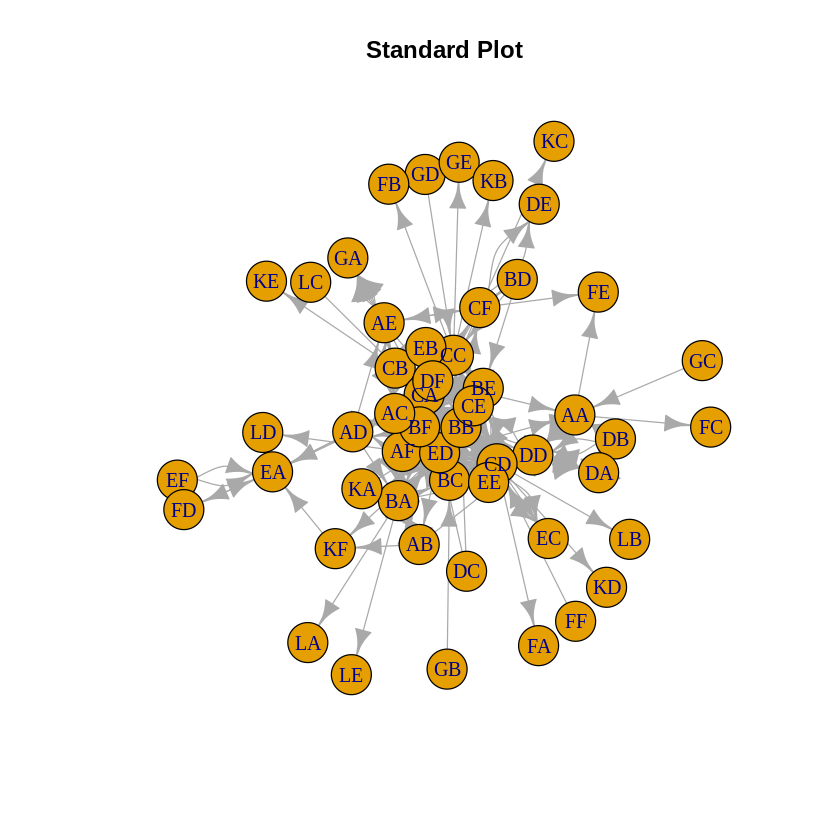

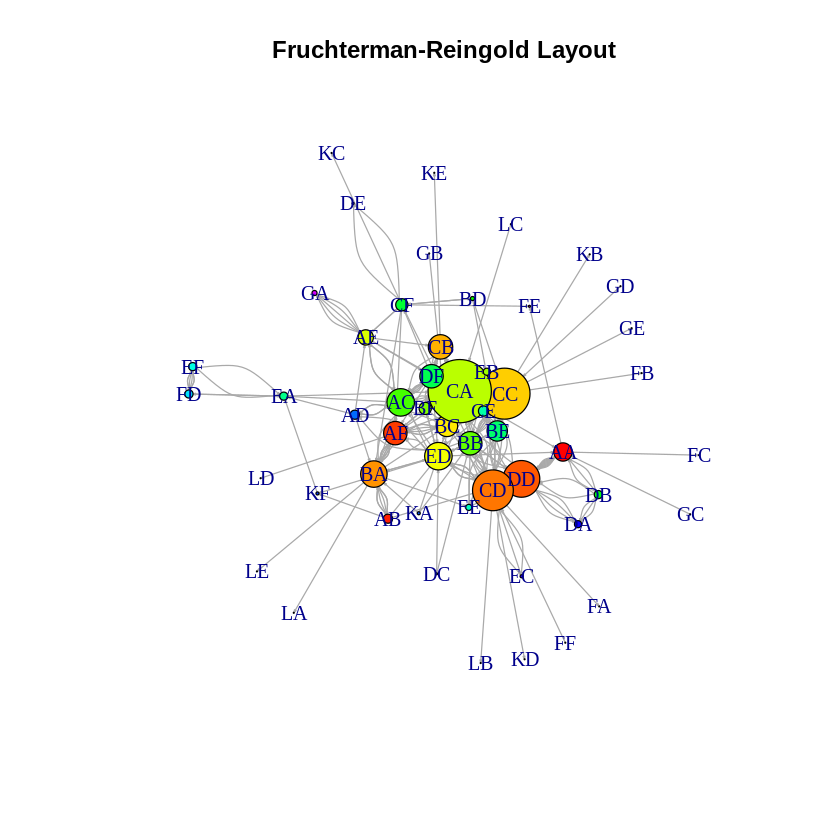

In [ ]:
plot(net, main = "Standard Plot")

plot(net,
     vertex.color = rainbow(52),
     vertex.size = V(net)$degree * 0.4,
     edge.arrow.size = 0.1,
     layout = layout_with_fr,
     main = "Fruchterman-Reingold Layout")

## **Hubs and Authorities**

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead.”


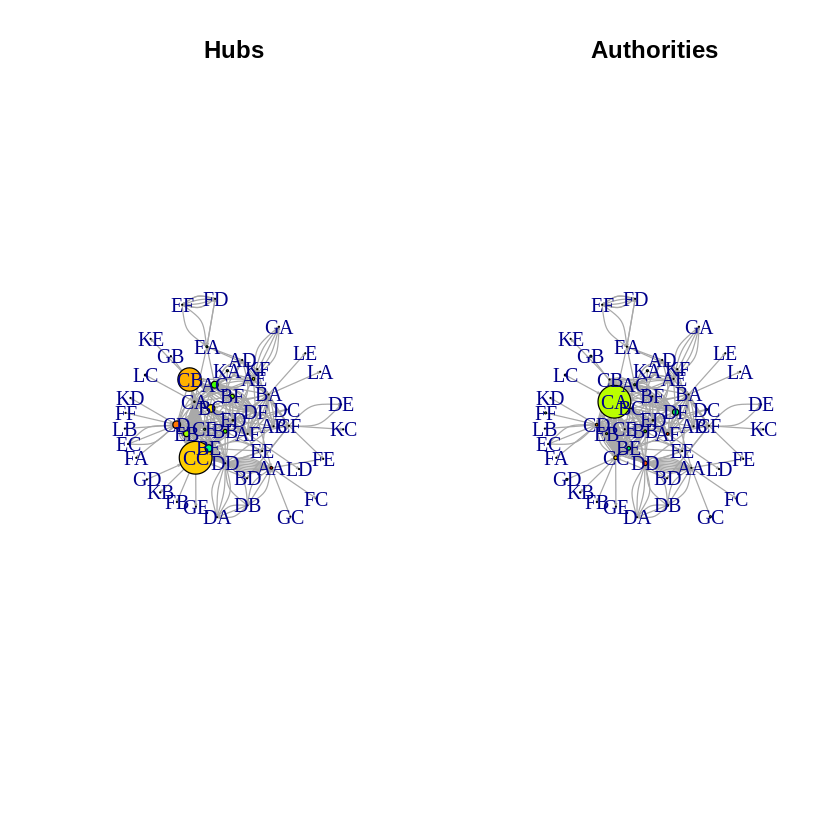

In [ ]:
# Calculate scores
hs <- hub_score(net)$vector
as <- authority_score(net)$vector

par(mfrow=c(1,2))
set.seed(123)

# Plot Hubs using Kamada-Kawai layout
plot(net,
     vertex.size = hs * 30,
     main = 'Hubs',
     vertex.color = rainbow(52),
     edge.arrow.size = 0.1,
     layout = layout_with_kk)

# Plot Authorities using Kamada-Kawai layout
plot(net,
     vertex.size = as * 30,
     main = 'Authorities',
     vertex.color = rainbow(52),
     edge.arrow.size = 0.1,
     layout = layout_with_kk)

# Reset plotting area to default
par(mfrow=c(1,1))

## **Community Detection**

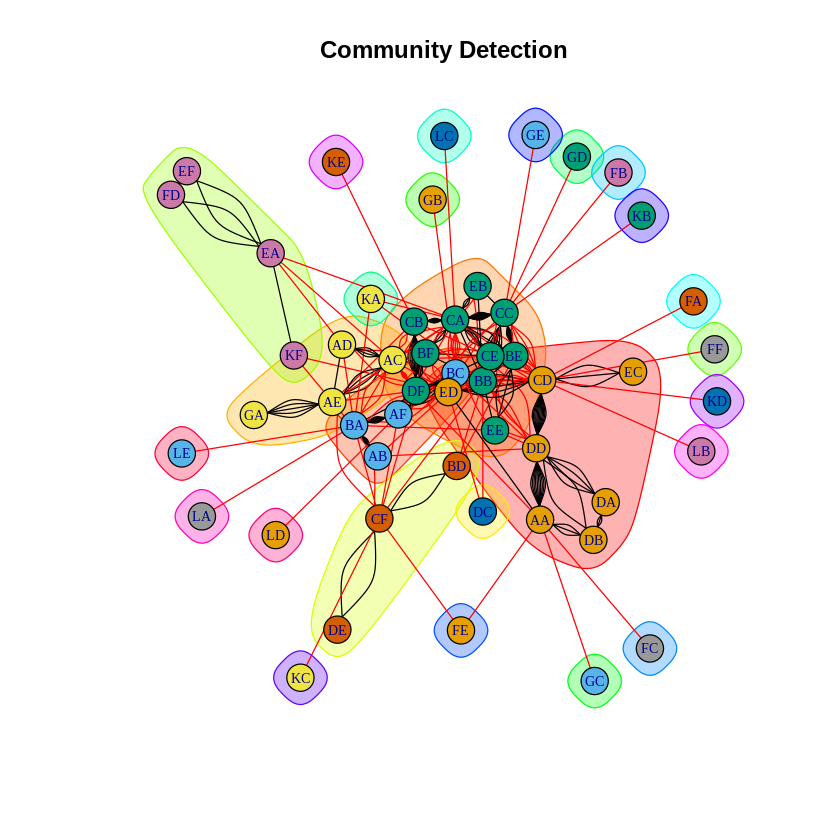

In [ ]:
# Re-create the network as undirected for community detection
net_undirected <- graph_from_data_frame(y, directed = FALSE)

# Detect communities using edge betweenness
cnet <- cluster_edge_betweenness(net_undirected)

# Plot the detected communities
plot(cnet, net_undirected,
     main = "Community Detection",
     vertex.size = 10,
     vertex.label.cex = 0.7)

## **Conclusion**

In this experiment, we used R and the igraph package to build, visualize, and make sense of social networks. By looking closely at how nodes connect to one another, we were able to pinpoint the key hubs and most influential players within the network. Finally, we used community detection to reveal the hidden structure of the data, showing how the broader network naturally divides into smaller groups.